In [2]:
from transformers import pipeline
import pandas as pd

/home/frankh/projects/GenAI_Python/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Classifier
task = "zero-shot-classification"
model = "facebook/bart-large-mnli"
classifier = pipeline(task=task, model=model)

Device set to use cpu


In [4]:
# Data Preparation
# first example: Jane Austen: Pride and Prejudice  (romantic novel)
# second example: Lewis Carroll: Alice's Adventures in Wonderland (fantasy novel)
# third example: Arthur Conan Doyle "The Return of Sherlock Holmes" (crime novel)
titles = ["Scuba Diving", "Soccer", "Golf"]
documents = [
    "Exploring the underwater world offers a unique and peaceful experience. Equipped with breathing gear, individuals can descend beneath the surface and observe vibrant marine ecosystems. Colorful fish, coral formations, and mysterious wrecks create a fascinating environment unlike anything on land. Proper training is essential to ensure safety, as awareness of depth, pressure, and air supply is crucial. Many people describe the sensation as calming, almost like floating in another world. This activity allows participants to connect deeply with nature while experiencing a sense of freedom and quiet that is hard to find elsewhere.",
    "This globally loved sport is played between two teams aiming to score by moving a ball into the opposing side’s goal. It is fast-paced and requires excellent coordination, teamwork, and strategic thinking. Players rely on quick passes, positioning, and communication to outperform their opponents. International competitions attract massive audiences and generate excitement around the world. The simplicity of the rules makes it accessible to people of all ages, while the depth of tactics keeps it challenging at higher levels. It is more than just a game—it brings communities together and inspires passion across cultures.",
    "This outdoor activity focuses on accuracy, control, and patience. Participants use a variety of clubs to guide a small ball across long distances into a sequence of targets. The environment often includes natural obstacles such as sand areas, water features, and uneven terrain, which increase the difficulty. Success depends not only on technique but also on mental focus and consistency. Many enjoy the slow pace and the opportunity to spend time in scenic surroundings. It is often played socially, offering a balance between competition and relaxation that appeals to a wide range of people."
]

In [5]:
# Labels to classify
candidate_labels = ["scuba diving", "soccer", "golf"]

In [6]:
# classify documents
result = classifier(documents, candidate_labels = candidate_labels)

<Axes: title={'center': 'Soccer'}, xlabel='labels'>

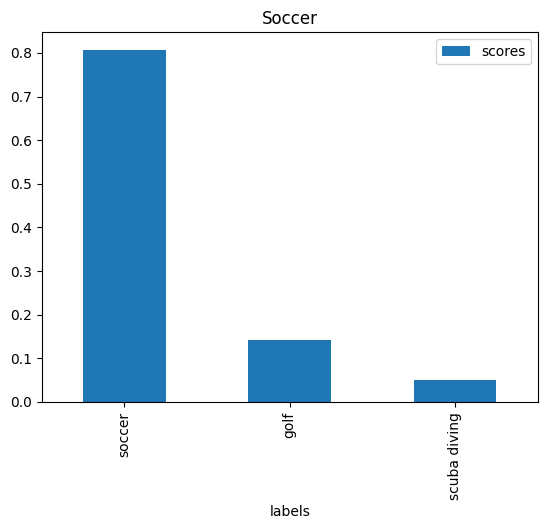

In [9]:
# visualize results
pos = 1
pd.DataFrame(result[pos]).plot.bar(x='labels', y='scores', title=titles[pos])